# NB05: Syntactic Analysis

## Language Processing

## LEI/2025-26

#### Nuno Macedo
Universidade do Minho



# 5.1 Syntactic Analysis

- **Syntactic analysis** is the second stage of the language-processing pipeline

- Unlike lexical analysis, which works over characters, syntactic analysis works over the *tokens* produced by the lexer

- A syntactic analyzer introduces and validates the structure of the language being processed
  - Its output is typically an **abstract syntax tree** (AST)

- **Context-free grammars** (CFGs) are commonly used to specify the syntax of computer languages
  - The alphabet of the grammar is usually the set of tokens produced by the lexer
  - A *parse tree* reflects the grammar directly, while the AST omits irrelevant syntactic detail

- This means that lexical analysis and syntactic analysis are interdependent
  - Decisions made at the lexer level directly affect the parser

- Although there are algorithms for parsing arbitrary CFGs, in practice we often restrict ourselves to more restricted grammar classes for efficiency and simplicity

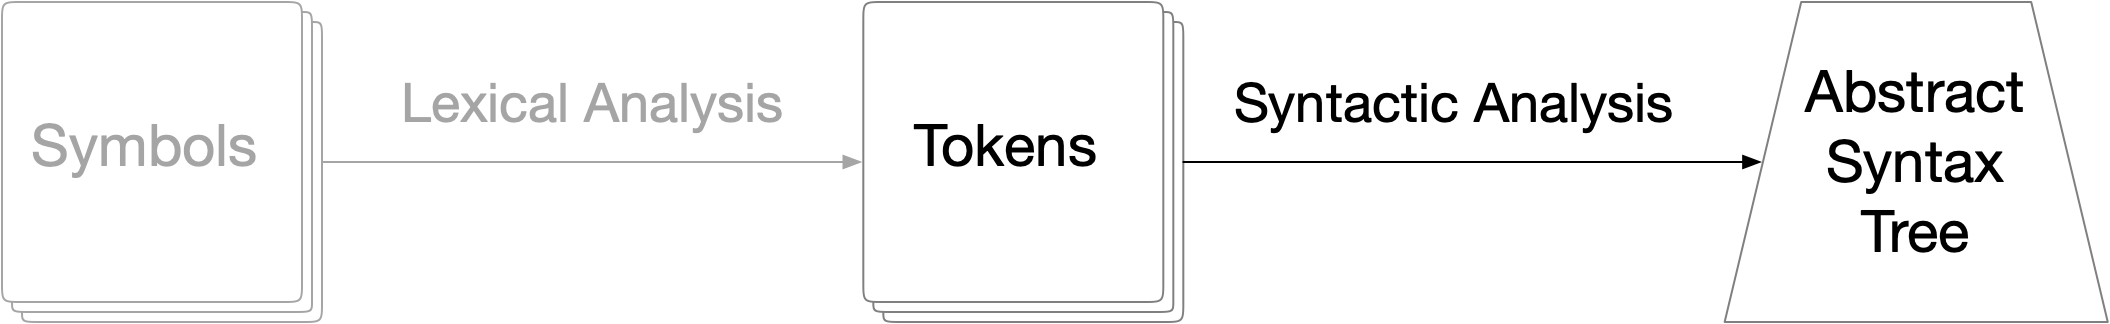

## ✏️ Pipeline example: A language for lists

- Consider a simple language of lists of integers:

  - `[10, 20, 12]`
  - `[10]`
  - `[]`




- A possible approach is for the CFG to work directly on input symbols.

- Let:
  - Σ = { `[`, `]`, `,` , `0`, `1`, ..., `9` }
  - $N$ = { `List`, `Elements`, `Int`, `Digit` }
  - $S_0$ = `List`

  ```
  List     → [ Elements ] | [ ]
  Elements → Int | Int , Elements
  Int      → Digit | Digit Int
  Digit    → 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9
  ```

- This grammar generates the intended language, but it places unnecessary burden on the parser, which must inspect every character of the input



- In practice, we would first run a lexer to tokenize the input, and let the parser work on a stream of tokens
  - Now the parser would only see integer tokens, and not digits

- This makes the grammar becomes simpler

- Let:
  - Σ = { `[`, `]`, `,` , `INT` }
  - $N$ = { `List`, `Elements` }
  - $S_0$ = `List`

  ```
  List     → [ Elements ] | [ ]
  Elements → INT | INT ',' Elements
  ```
  
- This grammar describes the same language at the syntactic level, but the parser no longer has to reconstruct integers from individual digits

- Usually, CFGs are written in BNF (Backus–Naur Form) notation, which uses different delimiters to identify tokens from nonterminals
  - Here we will just use a convention, tokens are written in full upper-case

# 5.2 Top-down Parsing

- **Top-down parsing** constructs a parse tree starting from the start symbol of the CFG and working toward the input

- At each step, the parser expands a nonterminal according to one of the CFG productions

- The goal is to choose productions so that the generated sentential form matches the input token stream

## Predictive parsing

- A parser must decide which production to use when expanding a nonterminal

- For the parser to be efficient, this choice should be made **predictively**:
  - it should choose the correct production without backtracking
  - it should rely only on a bounded amount of lookahead
  - this results in a parsing procedure with linear running time

- To do this, the parser can inspect one or more upcoming input tokens, called the **lookahead**

## LL($k$) parsing

- An **LL($k$) parser** is a *predictive* *top-down* parser that:
  - reads input **L**eft-to-right
  - constructs a **L**eftmost derivation
  - uses **$k$** lookahead tokens

- In particular, an **LL(1) parser** parser uses just one lookahead token to decide which production to apply
  - Here we will focus on this class, but the concepts generalize to larger lookaheads



## LL($k$) grammars and languages

- Not every grammar can be parsed by an LL($k$) parser
  - A grammar that can be parsed this way is called an **LL($k$) grammar**
  - A grammar may fail to be LL($n$) for some $n$, but still be LL($m$) for some $m > n$

- In some cases, a grammar that is not LL($k$) can be rewritten into an equivalent grammar that is LL($k$)
  - Typical transformations include removing left recursion and left factoring

- However, not every context-free language is an LL($k$) language for some finite $k$
  - A language that can be generated by some LL($k$) grammar is called an **LL($k$) language**

## Advantages and limitations

- LL parsers are useful because they are:
  - simple to implement
  - efficient, linear-time parsing
  - well suited for many programming language grammars

- However, they also have limitations:
  - many grammars are not LL($k$) for any finite $k$
  - some languages are not LL($k$) for any finite $k$
  - even when a language is LL($k$), its most natural grammar may not be
  - grammar transformations are often required before predictive parsing is possible

## LL(1) grammars

- An LL(1) parser is a predictive top-down parser that:
  - reads input Left-to-right
  - produces a Leftmost derivation
  - uses **1 lookahead token**

- To decide which production to apply, the parser uses **lookahead sets**

- To compute these sets we define, for each nonterminal `A` ∈ $N$:
  - $\mathrm{FIRST}(\mathtt{A})$ - terminals that can appear at the beginning of strings derived from `A`
  - $\mathrm{FOLLOWS}(\mathtt{A})$ - terminals that can appear immediately after
 `A`

### $\mathrm{FIRST}$ sets

$$
\begin{aligned}
\mathrm{FIRST}(\mathtt{a}) &= \{\mathtt{a}\}, \qquad \text{if } \mathtt{a} \in \Sigma \\[4pt]
\mathrm{FIRST}(\varepsilon) &= \{\varepsilon\} \\[6pt]
\mathrm{FIRST}(\mathtt{A}) &=
\bigcup_{\mathtt{A \rightarrow X_1 X_2 \ldots X_n} \in P}
\mathrm{FIRST}(\mathtt{X_1 X_2 \ldots X_n})
\end{aligned}
$$

That is, the $\mathrm{FIRST}$ set of a terminal or ε is the symbol itself; for a nonterminal, one must calculate the $\mathrm{FIRST}$ set of all its productions.

$$
\begin{aligned}
\mathrm{FIRST}(\mathtt{X_1 X_2 \ldots X_n}) &=
(\mathrm{FIRST}(\mathtt{X}_1) \setminus \{\varepsilon\}) \\
&\quad \cup
\begin{cases}
\mathrm{FIRST}(\mathtt{X_2 \ldots X_n}) & \text{if } \varepsilon \in \mathrm{FIRST}(\mathtt{X}_1) \\
\emptyset & \text{otherwise}
\end{cases}
\end{aligned}
$$

That is, the $\mathrm{FIRST}$ set of a (non-empty) production is the $\mathrm{FIRST}$ set of the first symbol of the production and, if that first symbol is *nullable*, the $\mathrm{FIRST}$ set of the production after that symbol.

### ✏️ $\mathrm{FIRST}$ sets example: A language for lists

- Revisiting the CFG:

  ```
  p1: List → [ Elements ]
  p2:      | [ ]
  p3: Elements → INT
  p4:          | INT , Elements
  ```

- For nonterminal `List`, there are two productions:

  $$
  \begin{align}
  &\mathrm{FIRST}(\mathtt{[} \ \mathtt{Elements} \ \mathtt{]}) = \mathrm{FIRST}(\mathtt{[}) = \{ \mathtt{[} \}\\
  &\mathrm{FIRST}(\mathtt{[} \ \mathtt{]}) = \mathrm{FIRST}(\mathtt{[}) = \{ \mathtt{[} \}
  \end{align}
  $$

- For nonterminal `Elements` there are also two productions:

  $$
  \begin{align}
  &\mathrm{FIRST}(\mathtt{INT}) = \{ \mathtt{INT} \}\\
  &\mathrm{FIRST}(\mathtt{INT} \ \mathtt{,} \ \mathtt{Elements}) = \mathrm{FIRST}(\mathtt{INT}) = \{ \mathtt{INT} \}
  \end{align}
  $$




### $\mathrm{FOLLOW}$ sets

$\mathrm{FOLLOW}(\mathtt{A})$ sets are calculated as a *fixed point*.

- Let `S` be the grammar's start symbol, and `$` ∈ Σ be a special terminal symbol representing the end of input. Then the process starts with
  $$
  \mathrm{FOLLOW}(S) = \{\$\}
  $$

- Afterwards, for any nonterminal `B`, search what may follow it when it appears on the right-hand side of productions and expand it $\mathrm{FOLLOW}$ set.

$$
\begin{aligned}
\text{If } \mathtt{A → X_1 \ldots X_n \ B \ Y_1 \ldots Y_m}, \text{ then } &
\mathrm{FOLLOW}(\mathtt{B}) \supseteq \mathrm{FIRST}(\mathtt{Y_1 \ldots Y_m}) \setminus \{\varepsilon\} \\[8pt]
\text{If } \mathtt{A → X_1 \ldots X_n \ B \ Y_1 \ldots Y_m} \text{ and }
\varepsilon \in \mathrm{FIRST}(\mathtt{Y_1 \ldots Y_m}), \text{ then } &
\mathrm{FOLLOW}(\mathtt{B}) \supseteq \mathrm{FOLLOW}(\mathtt{A}) \\[8pt]
\text{If } \mathtt{A → X_1 \ldots X_n \ B}, \text{ then } &
\mathrm{FOLLOW}(\mathtt{B}) \supseteq \mathrm{FOLLOW}(\mathtt{A})
\end{aligned}
$$

### ✏️ $\mathrm{FOLLOW}$ sets example: A language for lists

- The start symbol is `List` and it does not appear in the right-hand side of any production
  - $\mathrm{FOLLOW}(\mathtt{List}) = \{ \$ \}$

- The nonterminal `Elements` appears in the right-hand side of two productions
  - `List → [ Elements ]`, so `]` belongs to $\mathrm{FOLLOW}(\mathtt{Elements})$
  - `Elements → INT , Elements`, but since it appears last, we must calculate $\mathrm{FOLLOW}(\mathtt{Elements})$; that is what we were already calculating, so we have reached the fixed point
  - $\mathrm{FOLLOW}(\mathtt{Elements}) = \{ \mathtt{]} \}$





### LL(1) predictive parsing table

- The predictive parsing table will tell the parser which production to apply when expanding a nonterminal `A` given the lookahead token `a`

- A nonterminal `A` with lookahead `a` is expanded with production `p` for `A` if, and only if:
  - $\mathtt{a} \in \mathrm{FIRST}(\mathtt{p})$, or
  - $ɛ \in \mathrm{FIRST}(\mathtt{p})$ and $\mathtt{a} \in \mathrm{FOLLOW}(\mathtt{A})$

### LL(1) conflicts

- For a nonterminal `A` and a lookahead `a`:
  - If there are two productions `p1` and `p2` for `A` such that $\mathrm{FIRST}(p_1)$ and $\mathrm{FIRST}(p_2)$ intersect, then there is a **$\mathrm{FIRST}/\mathrm{FIRST}$ conflict**
    - Left-recursion in a production always leads to $\mathrm{FIRST}/\mathrm{FIRST}$ conflicts
  
  - If a production `p1` for `A` is nullable ($\varepsilon \in \mathrm{FIRST}(p_1)$) and $\mathrm{FOLLOW}(\mathtt{A})$ intersects $\mathrm{FIRST}(p_2)$ for another production `p2`, then there is a **$\mathrm{FIRST}/\mathrm{FOLLOW}$ conflict**

- The **LL(1) condition** is, thus, that for every nonterminal `A`, and productions $p_i$ and $p_j$ for `A`:

  $
  \begin{align}
  &\mathrm{FIRST}(p_i) \cap \mathrm{FIRST}(p_j) = ∅, \textrm{if } i \neq j \\
  & \mathrm{FIRST}(p_j) \cap \mathrm{FOLLOW}(\mathtt{A}) = ∅, \textrm{if } \varepsilon \in \mathrm{FIRST}(p_i)
  \end{align}
  $

- A grammar is LL(1) if there are no $\mathrm{FIRST}/\mathrm{FIRST}$ nor $\mathrm{FIRST}/\mathrm{FOLLOW}$ conflicts


### ✏️ LL(1) conflicts example: A language for lists

- For nonterminal `List`, $\mathrm{FIRST}(p_1) \cap \mathrm{FIRST}(p_2) = \{ \mathtt{[}\}\neq ∅$, there is a $\mathrm{FIRST}/\mathrm{FIRST}$ conflict

- For nonterminal `Elements`, $\mathrm{FIRST}(p_3) \cap \mathrm{FIRST}(p_4) = \{\mathtt{INT}\} \neq ∅$, , there is a $\mathrm{FIRST}/\mathrm{FIRST}$ conflict


- Thus, the grammar is not LL(1), and it is impossible to implement an LL(1) parser for it:
  - When expanding `List`, it is not possible to decide whether to apply `p1` or `p2`
  - Likewise for `Elements` and `p3` or `p4`




### LL(1) rewritting

- Often, if the language is LL(1), we can convert a non-LL(1) grammar into a LL(1) version by:
  - Removing left-recursion
  - Factoring out common first elements

- This may result is a grammar parsable by top-down strategies, but less readable to humans

- But recall that not all languages are LL(1)

### ✏️ LL(1) rewritting example: A language for lists

- The CFG has no left recursion, so let's try to factor out the first symbols to fix the $\mathrm{FIRST}$/$\mathrm{FIRST}$ conclicts

  ```
  p1: List         → [ RestList
  p2: RestList     → Elements ]
  p3:              | ]
  p4: Elements     → INT RestElements
  p5: RestElements → , Elements
  p6: RestElements | ɛ
  ```


- Let us calculate again the $\mathrm{FIRST}$ and $\mathrm{FOLLOW}$ sets

- For nonterminal `List`:

    \begin{align}
    &\mathrm{FIRST}(\mathtt{[} \ \mathtt{RestList}) = \{ \mathtt{[} \}
    \end{align}
    
- For nonterminal `RestList`:

    \begin{align}
    &\mathrm{FIRST}(\mathtt{Elements} \ \mathtt{]}) = \mathrm{FIRST}(\mathtt{Elements}) = \mathrm{FIRST}(\mathtt{INT} \ \mathtt{RestElements}) = \{ \mathtt{INT} \}\\
    &\mathrm{FIRST}(\mathtt{]}) = \{ \mathtt{]} \}
    \end{align}
    

    - No conflict for `RestList` since $\mathrm{FIRST}(p_2) \cap \mathrm{FIRST}(p_3) = ∅$

- For nonterminal `Elements`:

    \begin{align}
    &\mathrm{FIRST}(\mathtt{INT} \ \mathtt{RestElements}) = \{ \mathtt{INT} \}
    \end{align}

- For nonterminal `RestElements`:

    \begin{align}
    &\mathrm{FIRST}(\mathtt{,} \ \texttt{Elements}) = \{ \mathtt{,} \}
    &\mathrm{FIRST}(\varepsilon) = \{ \varepsilon \}\\
    \end{align}

    - No $\mathrm{FIRST}$/$\mathrm{FIRST}$ conflict, but since `RestElements` is nullable ($\varepsilon \in \mathrm{FIRST}(p_6)$), we also need to consider $\textrm{FOLLOW}(\mathtt{RestElements})$

    - `RestElements` only appears in the right-hand side of `p4: Elements → INT RestElements`

    - Since it is the last symbol, we must now find $\mathrm{FOLLOW}(\mathtt{Elements})$

    - `Elements` appears in the right-hand side of `p2` and `p5`
      - From `RestList → Elements ]` we obtain `]` in $\textrm{FOLLOW}(\mathtt{Elements})$
      - From `RestElements → , Elements`, since `Elements` is last, we add $\textrm{FOLLOW}(\mathtt{RestElements})$ to $\textrm{FOLLOW}(\mathtt{Elements})$, which was the starting point

    - So $\textrm{FOLLOW}(\mathtt{RestElements}) = \{ \texttt{]}\}$

    - Since $\textrm{FIRST}(\mathtt{\mathtt{]}}) \cap \textrm{FOLLOW}(\mathtt{RestElements}) = \emptyset$ and $\textrm{FIRST}(ɛ) \cap \textrm{FOLLOW}(\mathtt{RestElements}) = \emptyset$, there are no $\mathrm{FIRST}$/$\mathrm{FOLLOW}$ conflicts

### ✏️ LL(1) parsing table example: A language for lists

- Now that we have shown that the CFG is LL(1), we can us the $\mathrm{FIRST}$ and $\mathrm{FIRST}$ sets to construct the parsing table

- All entries use the $\mathrm{FIRST}$ set of productions except for `RestElements` with lookahead `]`: since `p6` is nullable, the $\mathrm{FOLLOW}$ set was used

  |                | `[`    | `]`   | `,`    | `INT`   |`$`|  
  |----------------|--------|-------|--------|---------|---|
  | `List`         | p1     |       |        |         |   |   
  | `RestList`     |        | p3    |        |  p2     |   |   
  | `Elements`     |        |       |        |  p4     |   |   
  | `RestElements` |        | p6    | p5     |         |   |   

## Implementing predictive parsing

The predictive choices encoded in an LL(1) parsing table can be implemented in two main ways:
  - recursive descent parsing
  - table-driven parsing

### Recursive descent parsing

- A recursive descent parser implements predictive parsing using functions:
  - each nonterminal corresponds to one function
  - each production corresponds to one branch inside that function

- Recursive descent parsers:
  - closely mirror the structure of the grammar
  - are simple to implement by hand

### Processing terminals

- To recognize a terminal, we check whether the next token has the expected type

- We could have a function `recognize_a()` for each token type `a`, but a generic helper function is enough:

  ```python
  def recognize_terminal(expected_type):
    token_type, token_val, token_line, token_pos = lookahead()
    if token_type == expected_type:
      next_token()
      return token_val
    else:
      raise ParseError(f"Unexpected token when recognizing terminal {expected_type}: {token_type}")
  ```

### Processing nonterminals

- For a nonterminal `A`, we create one branch for each relevant parsing table entry

- Suppose

  ```
  p1: A → X1 X2 ... Xn
  px: A → ...
  pk: A → Y1 Y2 ... Ym
  ```
  
  and the parsing table says `A` expands with `p1` with lookahead `x`, and with `pn` with lookahead `y`

- The skeleton for the function for recognizing `A` would be:

  ```python
  def recognize_A():
    token_type, token_val, token_line, token_pos = lookahead()
    if token_type == "x":
      # p1: A → X1 X2 ... Xn
      x1 = recognize_X1()
      x2 = recognize_X2()
      ...
      xn = recognize_Xn()
      return process(x1,x2,...,xn)
    elif ...:
      ...
    elif token_type == "y":
      # pk: A → Y1 Y2 ... Ym
      y1 = recognize_Y1()
      y2 = recognize_Y2()
      ...
      ym = recognize_Ym()
      return process(y1,y2,...,ym)
    else:
      raise ParseError(f"Unexpected token when recognizing nonterminal A: {token_type}")
  ```



- The values returned by these functions depend on the goal of the parser:
  - If we only want to **recognize** the input (check whether it is syntactically valid), the functions do not need to return anything
  - If we want to **build an abstract syntax tree** (AST), each branch should return the corresponding node
  - Alternatively, the parser can perform **semantic actions**, such as interpreting or evaluating the code while parsing

### ✏️ Recursive descent parser example: A language for lists

Let us define recursive descent parser for the following LL(1) grammar:

```
p1: List         → [ RestList
p2: RestList     → Elements ]
p3:              → ]
p4: Elements     → INT RestElements
p5: RestElements → , Elements
p6:              → ε
```

- First, we define the lexer (here, we will use `Ply.lex`)

In [ ]:
!pip install ply
__file__ = "Untitled.ipynb" # needed to run Ply inside notebook

In [ ]:
import ply.lex as lex

class LexError(Exception):
    pass

tokens = ("INT",)
literals = "[],"

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t\n"

def t_error(t):
  raise LexError(f"Invalid symbol: {t.value[0]}")

lexer = lex.lex()

_lookahead = None

# asks the lexer for the next token
def next_token():
  global _lookahead
  _lookahead = lexer.token()

# auxiliary function for token type, returns special end of input $ token if no more tokens
def lookahead():
  return (_lookahead.type,_lookahead.value,_lookahead.lineno,_lookahead.lexpos) if _lookahead else ("$",None,None,None)

- Next, define the function to recognize terminals

In [ ]:
class ParseError(Exception):
    pass

# generic function to recognize terminals
def recognize_terminal(expected_type):
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == expected_type:
    next_token()
    return token_val
  else:
    raise ParseError(f"Unexpected token when recognizing terminal {expected_type}: {token_type}")

- Lastly, using the parsing table defined above, define the functions to recognize nonterminals

In [ ]:
def recognize_List():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "[":     # p1: List         → [ RestList
    print("Applying p1: List         → [ RestList")
    recognize_terminal("[")
    recognize_RestList()
    print("Recognized p1: List         → [ RestList")
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'List': {token_type}")

def recognize_RestList():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":   # p2: RestList     → Elements ]
    print("Applying p2: RestList     → Elements ]")
    recognize_Elements()
    recognize_terminal("]")
    print("Recognized p2: RestList     → Elements ]")
  elif token_type == "]":   # p3:              | ]
    print("Applying p3:              | ]")
    recognize_terminal("]")
    print("Recognized p3:              | ]")
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'RestList': {token_type}")

def recognize_Elements():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":   # p4: Elements     → INT RestElements
    print("Applying p4: Elements     → INT RestElements")
    recognize_terminal("INT")
    recognize_RestElements()
    print("Recognized p4: Elements     → INT RestElements")
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'Elements': {token_type}")

def recognize_RestElements():
  token_type, token_val, token_line, token_col = lookahead()
  if token_type == ",":     # p5: RestElements → , Elements
    print("Applying p5: RestElements → , Elements")
    recognize_terminal(",")
    recognize_Elements()
    print("Recognized p5: RestElements → , Elements")
  elif token_type == "]":   # p6:              | ɛ
    print("Applying p6:              | ɛ")
    pass
    print("Recognized p6:              | ɛ")
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'RestElements': {token_type}")

- Now, start from the initial symbol, `List`, and check whether the input is exactly recognized as a `List`

In [ ]:
def parse(text):
  lexer.input(text)
  next_token()
  recognize_List()
  if lookahead()[0] != "$":
    raise ParseError(f"Unexpected extra input: {lookahead()[0]}")

In [ ]:
parse("[10, 20, 30]")

Applying p1: List         → [ RestList
Applying p2: RestList     → Elements ]
Applying p4: Elements     → INT RestElements
Applying p5: RestElements → , Elements
Applying p4: Elements     → INT RestElements
Applying p5: RestElements → , Elements
Applying p4: Elements     → INT RestElements
Applying p6:              | ɛ
Recognized p6:              | ɛ
Recognized p4: Elements     → INT RestElements
Recognized p5: RestElements → , Elements
Recognized p4: Elements     → INT RestElements
Recognized p5: RestElements → , Elements
Recognized p4: Elements     → INT RestElements
Recognized p2: RestList     → Elements ]
Recognized p1: List         → [ RestList


In [ ]:
parse("[10]")

Applying p1: List         → [ RestList
Applying p2: RestList     → Elements ]
Applying p4: Elements     → INT RestElements
Applying p6:              | ɛ
Recognized p6:              | ɛ
Recognized p4: Elements     → INT RestElements
Recognized p2: RestList     → Elements ]
Recognized p1: List         → [ RestList


In [ ]:
parse("[]")

Applying p1: List         → [ RestList
Applying p3:              | ]
Recognized p3:              | ]
Recognized p1: List         → [ RestList


In [ ]:
parse("[10, ]")

Applying p1: List         → [ RestList
Applying p2: RestList     → Elements ]
Applying p4: Elements     → INT RestElements
Applying p5: RestElements → , Elements


ParseError: Unexpected token when recognizing nonterminal 'Elements': ]

In [ ]:
parse("[10, 20")

In [ ]:
parse("[10 20]")

### Table-driven predictive parser

- Instead of hardcoding the decisions in code, the parser can consult the table directly

- The parser maintains:
  - a stack of grammar symbols
  - a lookahead token

- At each step:
  - inspect the stack top
  - inspect the lookahead token
  - consult the table
  - apply the corresponding production

In [ ]:
def generate(start,terminals,parse_table,productions):
  def parser(text):
    lexer.input(text)
    next_token()
    stack = ["$", start]

    while stack:
      next_symbol = stack.pop()
      token_type, token_val, token_line, token_pos = lookahead()

      if next_symbol in terminals:
          if next_symbol == token_type:
            next_token()
          else:
            raise ParseError(f"Unexpected token when recognizing terminal {next_symbol}: {token_type}")
      else:
        next_production = parse_table.get((next_symbol,token_type))
        if not next_production:
          raise ParseError(f"Unexpected token when recognizing nonterminal {next_symbol}: {token_type}")
        else:
          rhs = productions[next_production]
          print(f"Applying {next_production}: {next_symbol} → {rhs}")
          stack.extend(rhs[::-1])
  return parser

### ✏️ Table-driven predictive parser example: A language for lists



Start by encoding the parsing table and the production's right-hand side as a dictionaries.

  ```
  p1: List         → [ RestList
  p2: RestList     → Elements ]
  p3:              | ]
  p4: Elements     → INT RestElements
  p5: RestElements → , Elements
  p6:              | ɛ
  ```
  

  |                | `[`    | `]`   | `,`    | `INT`   |`$``
|  
  |----------------|--------|-------|--------|---------|---|
  | `List`         | p1     |       |        |         |   |   
  | `RestList`     |        | p3    |        |  p2     |   |   
  | `Elements`     |        |       |        |  p4     |   |   
  | `RestElements` |        | p6    | p5     |         |   |   

In [ ]:
parse_table = {
    ("List","[") : "p1",
    ("RestList","]") : "p3",
    ("RestList","INT") : "p2",
    ("Elements","INT") : "p4",
    ("RestElements",",") : "p5",
    ("RestElements","]") : "p6"
}

terminals = ("[","]",",","INT","$")

productions = {
    "p1": ["[", "RestList"],
    "p2": ["Elements", "]"],
    "p3": ["]"],
    "p4": ["INT", "RestElements"],
    "p5": [",", "Elements"],
    "p6": []
}

In [ ]:
parse = generate("List",terminals,parse_table,productions)

In [ ]:
parse("[10, 20, 30]")

In [ ]:
parse("[10]")

In [ ]:
parse("[]")

In [ ]:
parse("[10, ]")

In [ ]:
parse("[10, 20")

In [ ]:
parse("[10 20]")

## 🛠 LL(1) exercise: Simple arithmetic expressions

- Consider the following CFG:

  ```
  p1: E → E + T
  p2:   | T
  p3: T → T * F
  p4:   | F
  p5: F → INT
  ```

- This grammar expresses:
  - `*` has higher precedence than `+`
  - both operators are left-associative

- This grammar is good for expressing structure, but is it suitable for LL(1) parsing?
  - Check the LL(1) condition for the CFG
  - If the condition fails, rewrite it to an LL(1) version
  - Implement a LL(1) parser for the language generated by the grammar

- The CFG has left recursion in productions `p1` and `p3`

- Immediate left recursion prevents LL(1) parsing, because productions for the same nonterminal have overlapping predictive choices

- We can remove left recursion by introducing new productions

  ```
  p1: E     → T ERest
  p2: ERest → + T ERest
  p3:       | ε
  p4: T     → F TRest
  p5: TRest → * F TRest
  p6:       | ε
  p7: F     → INT
  ```

- This grammar is equivalent (generates the same strings) but the resulting parse trees are different
  - In particular, it no longer associates to the left
  - This is not problematic because `+` and `*` are associative
  - But would be if we also supported `-` and `/`

- $\textrm{FIRST}$ sets

  $\begin{align}
  &\textrm{FIRST}(\mathtt{T}\ \mathtt{ERest})  = \{ \mathtt{INT} \} \\
  &\textrm{FIRST}(\mathtt{+} \ \mathtt{T}\ \mathtt{ERest}) = \{ \mathtt{+}\}\\
  &\textrm{FIRST}(ɛ) = \{ ɛ \}\\
  &\textrm{FIRST}(\mathtt{T})  = \{ \mathtt{INT} \} \\
  &\textrm{FIRST}(\mathtt{*} \ \mathtt{F}\ \mathtt{TRest}) = \{ \mathtt{*}\}\\
  &\textrm{FIRST}(ɛ) = \{ ɛ \}\\
  &\textrm{FIRST}(\mathtt{INT})  = \{ \mathtt{INT} \} \\
  \end{align}$

- $\textrm{FOLLOW}$ sets

  $\begin{align}
  &\textrm{FOLLOW}(\mathtt{E})  = \{ \$ \} \\
  &\textrm{FOLLOW}(\mathtt{E'}) = \{ \$ \} \\
  &\textrm{FOLLOW}(\mathtt{T})  = \{ \mathtt{+}, \$ \} \\
  &\textrm{FOLLOW}(\mathtt{T'}) = \{ \mathtt{+}, \$ \} \\
  &\textrm{FOLLOW}(\mathtt{F})  = \{ \mathtt{*}, \mathtt{+}, \$ \} \\  
  \end{align}$

- Predictive parsing table

  |        | `+`  | `*`   | `INT`  |`$` |  
  |--------|------|-------|--------|----|
  | `E`    |      |       | p1     |    |   
  | `E'`   | p2   |       |        | p3 |   
  | `T`    |      |       | p4     |    |   
  | `T'`   | p6   | p5    |        | p6 |   
  | `F`    |      |       | p7     |    |     

In [ ]:
import ply.lex as lex

class LexError(Exception):
    pass

tokens = ("INT",)
literals = "+*"

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t\n"

def t_error(t):
    raise LexError(f"Invalid symbol: {t.value[0]}")

lexer = lex.lex()

_lookahead = None

def next_token():
    global _lookahead
    _lookahead = lexer.token()

def lookahead():
  return (_lookahead.type,_lookahead.value,_lookahead.lineno,_lookahead.lexpos) if _lookahead else ("$",None,None,None)

In [ ]:
class ParseError(Exception):
    pass

def recognize_terminal(expected_type):
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == expected_type:
    next_token()
    return token_val
  else:
    raise ParseError(f"Unexpected token when recognizing terminal {expected_type}: {token_type}")

def recognize_E():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":          # p1: E  → T ERest
    print("Applying p1: E  → T ERest")
    recognize_T()
    recognize_ERest()
    print("Recognized p1: E  → T ERest")
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal E: {token_type}")

def recognize_ERest():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "+":            # p2: ERest → + T ERest
    print("Applying p2: ERest → + T ERest")
    recognize_terminal("+")
    recognize_T()
    recognize_ERest()
    print("Recognized p2: ERest → + T ERest")
  elif token_type == "$":          # p3:    → ε
    print("Applying p3:    → ε")
    pass
    print("Recognized p3:    → ε")
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal E': {token_type}")

def recognize_T():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":          # p4: T  → F TRest
    print("Applying p4: T  → F TRest")
    recognize_F()
    recognize_TRest()
    print("Recognized p4: T  → F TRest")
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal T: {token_type}")

def recognize_TRest():
  token_type, token_val, token_line, token_col = lookahead()
  if token_type == "*":            # p5: TRest → * F TRest
    print("Applying p5: TRest → * F TRest")
    recognize_terminal("*")
    recognize_F()
    recognize_TRest()
    print("Recognized p5: TRest → * F TRest")
  elif token_type in ("+", "$"):   # p6:    → ε
    print("Applying p6:    → ε")
    pass
    print("Recognized p6:    → ε")
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal T': {token_type}")

def recognize_F():
  token_type, token_val, token_line, token_col = lookahead()
  if token_type == "INT":          # p7: F  → INT
    print("Applying p7: F  → INT")
    recognize_terminal("INT")
    print("Applying p7: F  → INT")
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal F: {token_type}")

def parse(text):
  lexer.input(text)
  next_token()
  recognize_E()
  if lookahead()[0] != "$":
    raise ParseError(f"Unexpected extra input: {lookahead()[0]}")

In [ ]:
parse("10 + 20")

In [ ]:
parse("10 * 23")

In [ ]:
parse("23 * 10 + 13")

In [ ]:
parse("23 ** 34")

In [ ]:
parse("12 * 23 +")

# 5.3 From Recognition to Structure

- So far, our parsers only recognize whether the input is **syntactically valid**

- For example:

   `[10, 20, 30]`

- There is are syntactic errors, so our parser simply reports *parse succeeded* ✅

- However, most real parsers do more than recognition

- Instead of only checking validity, the parser usually computes or constructs information about the input

## Returning values from parsing functions

- Previously, our functions only consumed tokens and applied productions; they returned nothing

- We can modify the parser so that functions functions return *semantic values associated with grammar symbols*
  - We call these **semantic actions**

- These values may represent:
  - computed results
  - structured data
  - intermediate representations

- In a recursive descendent parser, we are explicitly calling recursive functions and processing return values
  - We can pass information down in the recursive calls
  - We can pass information up combining the result of the recursive calls

## ✏️ Evaluation example: A language for lists

- Besides parsing our language for lists of integers, let us try to compute the *sum* of the list during parsing

- Recall the LL(1) grammar:
  ```
  p1: List         → [ RestList
  p2: RestList     → Elements ]
  p3:              | ]
  p4: Elements     → INT RestElements
  p5: RestElements → , Elements
  p6:              | ε
  ```

- The lexer and auxiliary functions remain the same; we only adapt the functions recognizing nonterminals
  - Recall that tokens already have a *value* assigned during lexing


In [ ]:
def recognize_List():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "[":     # p1: List         → [ RestList
    recognize_terminal("[")
    total = recognize_RestList()
    return total            # return the total of the actual list
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'List': {token_type}")

def recognize_RestList():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":   # p2: RestList     → Elements ]
    total = recognize_Elements()
    recognize_terminal("]")
    return total            # has elements, return their total
  elif token_type == "]":   # p3:              | ]
    recognize_terminal("]")
    return 0                # no elements, total is 0
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'RestList': {token_type}")

def recognize_Elements():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":   # p4: Elements     → INT RestElements
    elem = recognize_terminal("INT")
    elems = recognize_RestElements()
    return elem + elems     # an element plus the total of rest of the list
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'Elements': {token_type}")

def recognize_RestElements():
  token_type, token_val, token_line, token_col = lookahead()
  if token_type == ",":     # p5: RestElements → , Elements
    recognize_terminal(",")
    elems = recognize_Elements()
    return elems            # more elements, return their total
  elif token_type == "]":   # p6:              | ɛ
    return 0                # end of the list, total is 0
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'RestElements': {token_type}")

In [ ]:
def parse(text):
  lexer.input(text)
  next_token()
  result = recognize_List() # store the parsing result
  if lookahead()[0] != "$":
    raise ParseError(f"Unexpected extra input: {lookahead()[0]}")
  return result

In [ ]:
parse("[10, 20, 30]")

In [ ]:
parse("[10]")

In [ ]:
parse("[]")

## 🛠 Evaluation exercise: Simple arithmetic expressions

- Recall the following LL(1) CFG from the previous exercise:

  ```
  p1: E     → T ERest
  p2: ERest → + T ERest
  p3:       | ε
  p4: T     → F TRest
  p5: TRest → * F TRest
  p6:       | ε
  p7: F     → INT
  ```

- Write a top-down predictive parser to calculate the value of such expressions

In [ ]:
import ply.lex as lex

class LexError(Exception):
    pass

tokens = ("INT",)
literals = "+*"

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t\n"

def t_error(t):
    raise LexError(f"Invalid symbol: {t.value[0]}")

lexer = lex.lex()

_lookahead = None

def next_token():
    global _lookahead
    _lookahead = lexer.token()

def lookahead():
  return (_lookahead.type,_lookahead.value,_lookahead.lineno,_lookahead.lexpos) if _lookahead else ("$",None,None,None)

In [ ]:
class ParseError(Exception):
    pass

def recognize_terminal(expected_type):
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == expected_type:
    next_token()
    return token_val
  else:
    raise ParseError(f"Unexpected token when recognizing terminal {expected_type}: {token_type}")

def recognize_E():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":         # p1: E  → T ERest
    left = recognize_T()
    rest = recognize_ERest()
    return left + rest
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal E: {token_type}")

def recognize_ERest():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "+":           # p2: ERest → + T ERest
    recognize_terminal("+")
    right = recognize_T()
    rest = recognize_ERest()
    return right + rest
  elif token_type == "$":         # p3:    → ε
    return 0
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal E': {token_type}")

def recognize_T():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":         # p4: T  → F TRest
    left = recognize_F()
    rest = recognize_TRest()
    return left * rest
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal T: {token_type}")

def recognize_TRest():
  token_type, token_val, token_line, token_col = lookahead()
  if token_type == "*":           # p5: TRest → * F TRest
    recognize_terminal("*")
    right = recognize_F()
    rest = recognize_TRest()
    return right * rest
  elif token_type in ("+", "$"):  # p6:    → ε
    return 1
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal T': {token_type}")

def recognize_F():
  token_type, token_val, token_line, token_col = lookahead()
  if token_type == "INT":         # p7: F  → INT
    val = recognize_terminal("INT")
    return val
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal F: {token_type}")

def parse(text):
  lexer.input(text)
  next_token()
  tree = recognize_E()
  if lookahead()[0] != "$":
    raise ParseError(f"Unexpected extra input: {lookahead()[0]}")
  return tree

In [ ]:
parse("10 + 20")

In [ ]:
parse("10 + 20 * 30")

In [ ]:
parse("10 * 20 + 30")

In [ ]:
parse("10")

## Creating structured representations

- Often, we do not want to evaluate an input immediately

- Before evaluation, or generating the final representation, we may want to:
  - check for additional errors
  - perform additional translations
  - apply optimizations

- Therefore, we usually generate an **intermediate representation** that can be analyzed and transformed

## ✏️ Structured representation example: A language for lists

- Instead of computing the sum, let us try to construct a **structured representation** of the list

- In this example, we can build an actual Python list while parsing

- Again, the lexer and auxiliary functions remain unchanged

In [ ]:
def recognize_List():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "[":        # p1: List         → [ RestList
    recognize_terminal("[")
    elems = recognize_RestList()
    return elems               # return the elements of the actual list
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'List': {token_type}")

def recognize_RestList():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":      # p2: RestList     → Elements ]
    elems = recognize_Elements()
    recognize_terminal("]")    # has elements, return them
    return elems
  elif token_type == "]":      # p3:              | ]
    recognize_terminal("]")    # has no elements, return empty list
    return []
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'RestList': {token_type}")

def recognize_Elements():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":      # p4: Elements     → INT RestElements
    elem = recognize_terminal("INT")
    elems = recognize_RestElements()
    return [elem] + elems      # element followed by the elements of the rest of the list
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'Elements': {token_type}")

def recognize_RestElements():
  token_type, token_val, token_line, token_col = lookahead()
  if token_type == ",":        # p5: RestElements → , Elements
    recognize_terminal(",")
    elems = recognize_Elements()
    return elems               # has more elements, return them
  elif token_type == "]":      # p6:              | ɛ
    return []                  # no more elements, return empty list
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'RestElements': {token_type}")

In [ ]:
def parse(text):
  lexer.input(text)
  next_token()
  result = recognize_List()    # store the parsing result
  if lookahead()[0] != "$":
    raise ParseError(f"Unexpected extra input: {lookahead()[0]}")
  return result

In [ ]:
parse("[10, 20, 30]")

In [ ]:
parse("[10]")

In [ ]:
parse("[]")

## Abstract syntax trees

- Our current version of parser returns a Python list as a structured version of the input text

- This works well for this language because lists are a native data type in Python, but this is not the case in general

- In most cases, we want to construct an **Abstract Syntax Tree** (AST) as an intermediate representation during parsing

- An AST represents the essential structure of the input while abstracting away unnecessary syntactic details

- An AST is not the same as the *parse* tree
  - elements such as delimiters, separators, or auxiliary grammar symbols usually do not appear in the AST

- The AST is then used by later stages of the language processor, which may perform:
  - semantic analysis
  - program transformations
  - interpretation
  - code generation

## ✏️ AST example: A language for lists

- Returning a Python list is already useful, but it does not explicitly represent the *syntactic structure* of the language

- For example, an AST for the list `[10,20,30]` could be:

  ```
  List
  └─ Cons
      ├─ INT(10)
      └─ Cons
          ├─ INT(20)
          └─ Cons
              ├─ INT(30)
              └─ Nil
  ```

- In particular, this AST ignores elements such as:
  - delimiters `[` and `]`
  - separators `,`
  - auxiliary nonterminals introduced for parsing
  - this is different from the parse tree

      ```
      List
      ├─ [
      └─ RestList
          ├─ Elements
          │   ├─ INT(10)
          │   └─ RestElements
          │       ├─ ,
          │       └─ Elements
          │           ├─ INT(20)
          │           └─ RestElements
          │               ├─ ,
          │               └─ Elements
          │                   ├─ INT(30)
          │                   └─ RestElements
          │                       └─ ɛ
          └─ ]
      ```

- This AST can be represented using different data structures, for example:
  - simple nested tuples
  - classes representing AST nodes

### Tuple-based AST representation

- A simple way to represent an AST is using nested tuples

- For the list language we can define the following node types:
  
  ```
  ("List", elements)
  ("Cons", value, rest)
  ("Nil",)
  ```

- For example, the input text `[10,20,30]` becomes

  ```
  ("List",
      ("Cons", 10,
          ("Cons", 20,
              ("Cons", 30,
                  ("Nil",)))))
  ```

- This representation directly reflects the recursive structure of the grammar

- No need to change the structure of the parser, we just need to return the proper AST node

In [ ]:
def recognize_List():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "[":          # p1: List         → [ RestList
    recognize_terminal("[")
    elems = recognize_RestList()
    return ("List",elems)        # the top-level list node
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'List': {token_type}")

def recognize_RestList():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":        # p2: RestList     → Elements ]
    elems = recognize_Elements()
    recognize_terminal("]")
    return elems                 # list with elements, return that node
  elif token_type == "]":        # p3:              | ]
    recognize_terminal("]")
    return ("Nil",)              # empty list, return nil node
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'RestList': {token_type}")

def recognize_Elements():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":        # p4: Elements     → INT RestElements
    elem = recognize_terminal("INT")
    elems = recognize_RestElements()
    return ("Cons", elem, elems) # cons node, element followed by the rest of the list
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'Elements': {token_type}")

def recognize_RestElements():
  token_type, token_val, token_line, token_col = lookahead()
  if token_type == ",":          # p5: RestElements → , Elements
    recognize_terminal(",")
    elems = recognize_Elements()
    return elems                 # additional elements, return that node
  elif token_type == "]":        # p6:              | ɛ
    return ("Nil",)              # no more elements, return nil node
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'RestElements': {token_type}")

In [ ]:
def parse(text):
  lexer.input(text)
  next_token()
  result = recognize_List()      # store the parsing result
  if lookahead()[0] != "$":
    raise ParseError(f"Unexpected extra input: {lookahead()[0]}")
  return result

In [ ]:
parse("[10, 20, 30]")

In [ ]:
parse("[10]")

In [ ]:
parse("[]")

### Class-based AST representation

- Tuple-based ASTs are simple and sufficient for small examples

- However, they are not suitable for complex languages and transformations

- For a proper representation, we should define a class hierarchy for the AST

- For the list language we can define three node types: `ListNode`, `ConsNode`, and `NilNode`
  
- Then, we just need to have the parser instantiate the proper AST objects

In [ ]:
class ListNode:
  def __init__(self, elements):
    self.elements = elements

  def __repr__(self):
    return f"ListNode({self.elements})"

class ConsNode:
  def __init__(self, value, rest):
    self.value = value
    self.rest = rest

  def __repr__(self):
    return f"ConsNode({self.value}, {self.rest})"

class NilNode:
  def __repr__(self):
    return "NilNode()"

In [ ]:
def recognize_List():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "[":           # p1: List         → [ RestList
    recognize_terminal("[")
    elems = recognize_RestList()
    return ListNode(elems)        # the top-level list node
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'List': {token_type}")

def recognize_RestList():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":         # p2: RestList     → Elements ]
    elems = recognize_Elements()
    recognize_terminal("]")
    return elems                  # list with elements, return that node
  elif token_type == "]":         # p3:              | ]
    recognize_terminal("]")
    return NilNode()              # empty list, return nil node
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'RestList': {token_type}")

def recognize_Elements():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":         # p4: Elements     → INT RestElements
    elem = recognize_terminal("INT")
    elems = recognize_RestElements()
    return ConsNode(elem, elems)  # cons node, element followed by the rest of the list
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'Elements': {token_type}")

def recognize_RestElements():
  token_type, token_val, token_line, token_col = lookahead()
  if token_type == ",":           # p5: RestElements → , Elements
    recognize_terminal(",")
    elems = recognize_Elements()
    return elems                  # additional elements, return that node
  elif token_type == "]":         # p6:              | ɛ
    return NilNode()              # no more elements, return nil node
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal 'RestElements': {token_type}")

In [ ]:
def parse(text):
  lexer.input(text)
  next_token()
  result = recognize_List()       # store the parsing result
  if lookahead()[0] != "$":
    raise ParseError(f"Unexpected extra input: {lookahead()[0]}")
  return result

In [ ]:
parse("[10, 20, 30]")

In [ ]:
parse("[10]")

In [ ]:
parse("[]")

## 🛠 AST exercise: Simple arithmetic expressions


- Recall the following LL(1) CFG from the previous exercise:

  ```
  p1: E     → T ERest
  p2: ERest → + T ERest
  p3:       | ε
  p4: T     → F TRest
  p5: TRest → * F TRest
  p6:       | ε
  p7: F     → INT
  ```

- Write a top-down predictive parser to translate such expressions into an AST

- Recall that `+` and `*` associate to the left, but the LL(1) syntax tree associates to the right
  - This should be addressed when the AST is created

- Then, evaluate the value of the expression by traversing the AST

In [ ]:
import ply.lex as lex

class LexError(Exception):
    pass

tokens = ("INT",)
literals = "+*"

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t\n"

def t_error(t):
    raise LexError(f"Invalid symbol: {t.value[0]}")

lexer = lex.lex()

_lookahead = None

def next_token():
    global _lookahead
    _lookahead = lexer.token()

def lookahead():
  return (_lookahead.type,_lookahead.value,_lookahead.lineno,_lookahead.lexpos) if _lookahead else ("$",None,None,None)

In [ ]:
class ParseError(Exception):
    pass

def recognize_terminal(expected_type):
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == expected_type:
    next_token()
    return token_val
  else:
    raise ParseError(f"Unexpected token when recognizing terminal {expected_type}: {token_type}")

def recognize_E():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":         # p1: E  → T ERest
    left = recognize_T()
    return recognize_ERest(left)
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal E: {token_type}")

def recognize_ERest(left):
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "+":           # p2: ERest → + T ERest
    recognize_terminal("+")
    right = recognize_T()
    new = ("Add", left, right)
    return recognize_ERest(new)
  elif token_type == "$":         # p3:    → ε
    return left
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal E': {token_type}")

def recognize_T():
  token_type, token_val, token_line, token_pos = lookahead()
  if token_type == "INT":         # p4: T  → F TRest
    left = recognize_F()
    return recognize_TRest(left)
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal T: {token_type}")

def recognize_TRest(left):
  token_type, token_val, token_line, token_col = lookahead()
  if token_type == "*":           # p5: TRest → * F TRest
    recognize_terminal("*")
    right = recognize_F()
    new = ("Mul", left, right)
    return recognize_TRest(new)
  elif token_type in ("+", "$"):  # p6:    → ε
    return left
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal T': {token_type}")

def recognize_F():
  token_type, token_val, token_line, token_col = lookahead()
  if token_type == "INT":         # p7: F  → INT
    val = recognize_terminal("INT")
    return ("Val", val)
  else:
    raise ParseError(f"Unexpected token when recognizing nonterminal F: {token_type}")

def parse(text):
  lexer.input(text)
  next_token()
  tree = recognize_E()
  if lookahead()[0] != "$":
    raise ParseError(f"Unexpected extra input: {lookahead()[0]}")
  return tree

In [ ]:
parse("10 + 20")

In [ ]:
parse("10 + 20 * 30")

In [ ]:
parse("10")

In [ ]:
def eval(node):
    tag = node[0]

    if tag == "Val":
        return node[1]

    elif tag == "Add":
        left_val = eval(node[1])
        right_val = eval(node[2])
        return left_val + right_val

    elif tag == "Mul":
        left_val = eval(node[1])
        right_val = eval(node[2])
        return left_val * right_val

    else:
        raise ValueError(f"Unknown AST node: {tag}")

In [ ]:
eval(parse("10 + 20"))

In [ ]:
eval(parse("10 + 20 * 30"))

In [ ]:
eval(parse("10"))

## Top-down parsing in practice

- LL(1) parsing is simple, predictable and easy to implement by hand

- However, it is often **too restrictive** in practice:
  - many natural grammars are not LL(1)
  - require eliminating left recursion and factoring
  - limited to a single lookahead token
  
- Modern tools use more powerful top-down parsing:
  - allow more lookahead
  - handle more natural grammars

- Example:
  - [ANTLR](https://www.antlr.org/) (LL-based parser generator with arbitrary lookahead)

# 5.4 Bottom-up parsing



## Bottom-up vs top-down parsing

- **Top-down parsing** starts from the **start symbol** of the grammar and tries to derive the input string by expanding non-terminals
  - Constructs a **leftmost derivation**
  - Builds the parse tree from the **root downward**

- **Bottom-up parsing** starts from the **input string** and tries to reconstruct the derivation by recognizing substrings that match the right-hand side of productions, until only the start symbol remains
  - Constructs a **rightmost derivation in reverse**
  - Builds the parse tree from the **leaves upward**

- Instead of predicting structure, bottom-up parsing *recognizes structure*

## Rightmost derivation in reverse

- Bottom-up parsing is based on the idea of reconstructing a *rightmost derivation in reverse*

- The goal is to identify substrings in the string being processed that match the right-hand side of a production

- When such a substring is found, it can be **reduced** into the corresponding non-terminal
  - This corresponds to one step in the reversed rightmost derivation

- Bottom-up parsing consists of iteratively identifying substrings and reducing them, until we reach the start symbol

### ✏️ Derivation examples: Additive arithmetic expressions

Consider the following CFG with Σ = {`INT`, `+`, `-`} and $S_0$ = `E`:
```
p1: E → E + F
p2: E → E - F
p3: E → F
p4: F → INT
```

We want to check whether the string `1 + 2 - 3`, tokenized as `INT + INT - INT`, is generated by the grammar.

### Leftmost derivation

```
E ⇒ E - F
  ⇒ E + F - F
  ⇒ F + F - F
  ⇒ INT + F - F
  ⇒ INT + INT - F
  ⇒ INT + INT - INT
```

### Rightmost derivation

```
E ⇒ E - F
  ⇒ E - INT
  ⇒ E + F - INT
  ⇒ E + INT - INT
  ⇒ F + INT - INT
  ⇒ INT + INT - INT
```

### Rightmost derivation in reverse

```
INT + INT - INT
   ⇐ F + INT - INT
   ⇐ E + INT - INT
   ⇐ E + F - INT
   ⇐ E - INT
   ⇐ E - F
   ⇐ E
```

Each step will correspond to a reduction performed by a bottom-up parser

## Shift-reduce parsing

- Bottom-up parsing is typically implemented as **shift-reduce parsing**

- A shift-reduce parser maintains:
  - A **stack** of grammar symbols representing the processed portion of the input
  - An **input buffer** with the remaining symbols
  - A **decision mechanism** that determines the next action

- At each step, the parser performs one of these actions:
  - **Shift**: move the next input symbol onto the stack
  - **Reduce**: replace a *suffix of the stack* matching the right-hand side of a production with its left-hand side
  - **Accept**: the input has been successfully reduced to the start symbol
  - **Error**: no valid action is possible


### ✏️ Shift-reduce example: Additive arithmetic expressions

Let's simulate shift-reduce parsing with `INT + INT - INT`. To mark the end of the input, let's add the special token `$`.

| Stack     | Input buffer        | Action                |
| --------- | ------------------- | --------------------- |
| `ε`       | `INT + INT - INT $` | shift                 |
| `INT`     | `+ INT - INT $`     | reduce `p4: F → INT`  |
| `F`       | `+ INT - INT $`     | reduce `p3: E → F`    |
| `E`       | `+ INT - INT $`     | shift                 |
| `E +`     | `INT - INT $`       | shift                 |
| `E + INT` | `- INT $`           | reduce `p4: F → INT`  |
| `E + F`   | `- INT $`           | reduce `p1: E → E + F`|
| `E`       | `- INT $`           | shift                 |
| `E -`     | `INT $`             | shift                 |
| `E - INT` | `$`                 | reduce `p4: F → INT`  |
| `E - F`   | `$`                 | reduce `p2: E → E - F`|
| `E`       | `$`                 | accept                |


- Given a suitable CFG, a shift-reduce parser should be able to make these decisions automatically and efficiently
  - It should be a deterministical choice

- The central difficulty is *deciding when to shift and when to reduce*

- Making this decision may require symbol lookaheads






## LR($k$) parsing

- LR parsing provides a systematic solution to the shift/reduce decision problem:
  - which structures are complete and should be reduced
  - which structures are still in progress and require more input

- It does so by using a deterministic finite automaton (DFA) to keep parsing context

- An LR($k$) parser:
  - reads the input **L**eft-to-right
  - constructs a **R**ightmost derivation in reverse
  - uses **$k$** lookahead tokens to decide the next action

- At each step, the parser decides based on the current *state* and the next *$k$ input tokens* whether to:
  - shift
  - reduce, and with which production
  - accept
  - throw a parsing error

- This decision must be *deterministic*
  - There is no backtracking, the parsing procedure has linear running time

## LR(0) parsing

- We begin with the simplest variant: LR(0) parsing
  - LR(0) parsers *do not* use lookahead to make decisions
  - All decisions are made using only the current parser state

### The LR(0) automaton

- The LR(0) parser is controlled by an DFA where each state describes what has been recognized so far and what can come next
  - It will later give rise to a parsing table

- More specifically:
  - each **state** is represented by a set of *LR(0) items*
  - **transitions** represent how the parser advances when reading symbols

- Invalid transitions give rise to *syntactic errors*



### LR(0) items

- An *LR(0) item* is a grammar production annotated with a `•` marking what portion of that production has been recognized

- For instance:
  - `E →•E + F` means we are starting to recognize the production, expecting `E + F`; the production is not complete, we will need to shift more symbols
  - `E → E•+ F` means we have recognized an `E` in the stack and are expecting `+ F`; the production is not complete, we will need shift more symbols
  - `E → E + F•` means we have recognized an `E + F` in the stack; the production is complete, we will reduce that substring to `E`

### Item set closure

- Each state of the DFA contains not just one item, but a set of items

- Whenever an item is expecting a nonterminal, we must also add to the item set the productions that expand that nonterminal

- For instance:
  - If a state has an item `E → E +•F`, it is expecting an `F` next
  - Then it must also contain `F →•INT`, the only production for `F` in the grammar

- This is applied until a fixed point is reached

### Transitions

- The transitions from a state are determined by how a grammar symbol advances `•`

- For instance:
  - A state containing `E →•E + F` seeing `E` advances to a state containing the (closure) of `E → E•+ F`
  - A state containing `E → E•+ F` seeing `+` advances to a state containing the (closure) of `E → E +•F`

### Procedure to construct the DFA

- Given a CFG with an initial symbol `S`, start by expanding it with a special terminal `$` and a new production `S' → S $`

- The initial state of the DFA is the closure of `S' →•S $`

- Then, for all symbols of the CFG (terminals and nonterminals), determine the evolution of the item sets from the initial state

- Apply the closure to the resulting item sets, and create new states in the DFA

- Continue the process with the new states, until no more states are added to the DFA

- The accepting state is the one containing `S' → S $•`

### ✏️ LR(0) DFA example: Additive arithmetic expressions

Let's start by augmenting the previous grammar into Σ = {`INT`, `+`, `-`, `$`} and $S_0$ = `S`:
```
p0: S → E $
p1: E → E + F
p2: E → E - F
p3: E → F
p4: F → INT
```
- The initial state $I_0$ is the closure of `S →•E $`:
  - Since we have `•E` we also add `E →•E + F`, `E →•E + F` and `E →•F`
  - But now we also have `E →•F`, so we must also add `F →•INT`
  - So $I_0$ contains:
    - `S →•E $`
    - `E →•E + F`
    - `E →•E - F`
    - `E →•F`
    - `F →•INT`
  - $I_0$ has items with 3 symbols following a `•`, `E`, `F` and `INT`, so it will have 3 outgoing transitions

- From $I_0$ given `E`, we start the item set $I_1$ with:
  - `S → E•$`, `E → E•+ F` and `E → E•+ F`
  - There are no `•` before nonterminals, so there is no closure to apply
  - But there are `•` before terminals, it will have outgoing transitions

- From $I_0$ given `F`, we start the item set $I_2$ with:
  - `E → F•`
  - There are no `•` before nonterminals, so there is no closure to apply
  - This state only has `•` at the end, so it will have no outgoing transitions

- From $I_0$ given `INT`, we start the item set $I_3$ with:
  - `F → INT•`
  - There are no `•` before nonterminals, so there is no closure to apply
  - This state only has `•` at the end, so it will have no outgoing transitions

- From $I_1$ with `+`, we start the item set $I_4$ with:
  - `E → E +•F`
  - After applying the closure we get also `F →•INT`

- From $I_1$ with `-`, we start the item set $I_5$ with:
  - `E → E -•F`
  - After applying the closure we get also `F →•INT`

- From $I_1$ with `$`, we start the item set $I_6$ with:
  - `S → E $•`
  - This state only has `•` at the end, so it will have no outgoing transitions
  - This is the final/accepting state of the DFA

- From $I_4$ with `F`, we start the item set $I_7$ with:
  - `E → E + F•`
  - This state only has `•` at the end, so it will have no outgoing transitions

- From $I_4$ with `INT`, we get the item set:
  - `F → INT•`
  - This state already exists, it's $I_3$

- From $I_5$ with `F`, we start the item set $I_8$ with:
  - `E → E - F•`
  - This state only has `•` at the end, so it will have no outgoing transitions

- From $I_5$ with `INT`, we get the item set:
  - `F → INT•`
  - This state already exists, it's $I_3$



The resulting DFA is the following:

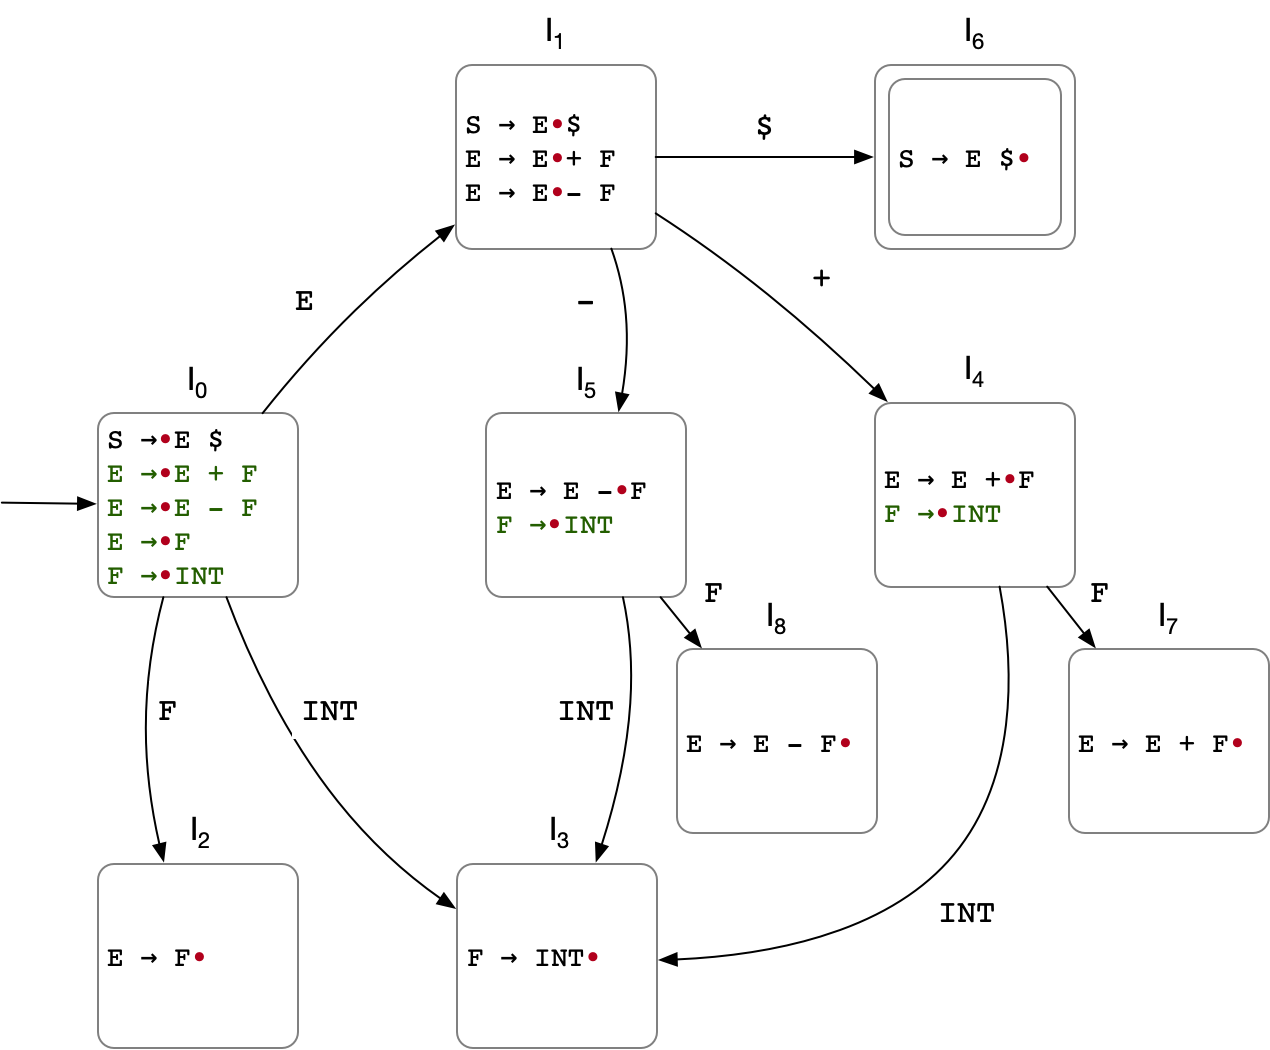

### LR(0) parsing tables

- From the DFA, we construct two parsing tables: an **action table** and a **goto table**

- An action table determines how, in a given state, the parser evolves when it sees a terminal:
    - `sn`: shift and change state to state $n$
    - `rm`: reduce using production $m$
    - `acc`: the word is recognized
    - otherwise: throw an error

- A shift action is selected if a state has outgoing transitions with that terminal
    
- A reduce action is selected in states with a single production with a `•` at the end
    - if a state has multiple items with `•` at the end there is a **reduce/reduce conflict**

- If a state has items `•` at the end and `•` before a terminal, there is **shift/reduce conflict**

- A goto table determines how, in a given state, the parser evolves when a nonterminal is created after a reduce
  - It uses the nonterminal transitions from a state
  - It simply identifies the succeeding state



### ✏️ LR(0) parsing table example: Additive arithmetic expressions

#### Action table

- In LR(0) the states that only have an item with `•` reduce regardless of the lookahead
  - $I_2$, $I_3$, $I_7$, $I_8$

- For the others, look for the transitions with terminals and shift
  - For instance, $I_0$ goes to $I_3$ when it sees `INT`

- The final state always accepts

  | State |`INT`| `+` |`-`  |`$`  |
  | ----- | --- | --- | --- | --- |
  | 0     |`s3` |     |     |     |
  | 1     |     |`s4` |`s5` |`s6` |
  | 2     |`r3` |`r3` |`r3` |`r3` |
  | 3     |`r4` |`r4` |`r4` |`r4` |
  | 4     |`s3` |     |     |     |
  | 5     |`s3` |     |     |     |
  | 6     |`acc`|`acc`|`acc`|`acc`|
  | 7     |`r1` |`r1` |`r1` |`r1` |
  | 8     |`r2` |`r2` |`r2` |`r2` |

#### Goto table

- Just look for the transitions between states with nonterminals

  | State |`E`  |`F` |
  | ----- | --- | -- |
  | 0     | 1   | 2  |
  | 1     |     |    |
  | 2     |     |    |
  | 3     |     |    |
  | 4     |     | 7  |
  | 5     |     | 8  |
  | 6     |     |    |
  | 7     |     |    |
  | 8     |     |    |


### Implementing the LR(0) parser

- The action and goto tables give us all the information we need to implement an LR parser

- The procedure registers a each step:
  - A stack alternating grammar symbols and parser states
    - The current state is the top of the stack
  - The remaining input buffer

- At each step, given the current state in the stack and the next symbol on the buffer, use the action table to determine the action
  - If the action is `acc` or invalid, the process terminates
  - If the action is a `sn`, shift the symbol to the stack and go to state `n`
  - If the action is a `rm`, and `pm : A → X0 ... Xl`
    - pop $l$ symbols from the stack (the size of production `pm`)
    - check the state at the top of the stack, and use the goto table with nonterminal `A` (the nonterminal resulting from the reduce)

### ✏️ LR(0) parsing example: Additive arithmetic expressions

Let's simulate LR(0) parsing with `INT + INT - INT $`, given the action and goto tables defined above.


| Stack                 | Input buffer        | Action          |
| --------------------- | ------------------- | --------------- |
| 0                     | `INT + INT - INT $` | `s3`            |
| 0 `INT` 3             | `+ INT - INT $`     | `r4`, goto 2    |
| 0 `F` 2               | `+ INT - INT $`     | `r3`, goto 1    |
| 0 `E` 1               | `+ INT - INT $`     | `s4`            |
| 0 `E` 1 `+` 4         | `INT - INT $`       | `s3`            |
| 0 `E` 1 `+` 4 `INT` 3 | `- INT $`           | `r4`, goto 7    |
| 0 `E` 1 `+` 4 `F` 7   | `- INT $`           | `r1`, goto 1    |
| 0 `E` 1               | `- INT $`           | `s5`            |
| 0 `E` 1 `-` 5         | `INT $`             | `s3`            |
| 0 `E` 1 `-` 5 `INT` 3 | `$`                 | `r4`, goto 8    |
| 0 `E` 1 `-` 5 `F` 8   | `$`                 | `r2`, goto 1    |
| 0 `E` 1               | `$`                 | `s6`            |
| 0 `E` 1 `$` 6         | ɛ                   | `acc`           |


## Expressive power of LR($k$)

- We say that a grammar is LR($k$) if it is possible to implement a LR($k$) parser for it

- Likewise, we say that a language is LR($k$) if there is a LR($k$) grammar for it

- Allowing more lookahead increases the class of grammars that can be handled without conflicts.
  - In particular, LR(0) grammars are the least expressive
  
- However, that is not the case for the classes of languages that can be addressed:
  - Any LR($k$) language is also an LR(1) language
  
- This means that any language that can be recognized by an LR parser can be generated by an LR(1) grammar
  - The LR(1) grammar may however be much larger than allowing more lookaheads

- LR(1) languages are precisely the *deterministic context-free languages*, those that can be recognized by a *deterministic* pushdown automaton (PDA)

- For a given $k$, LR($k$) grammars are also strictly more expressive than LL($k$) grammars

### ✏️ Beyond LR(0) example: Simple arithmetic expressions

- Let us consider a richer set of arithmetic expressions, with operators that have different precedence

- Consider the following grammar, with Σ = { `INT`, `+`, `*` } and $S_0$ = `E`

  ```
  p1: E → E + T
  p2: E → T
  p3: T → T * F
  p4: T → F
  p5: F → INT
  ```

- Let us try appply LR(0) shift-reduce parsing to `1 + 2 * 3 $` tokenized as `INT + INT * INT $`

  | Stack         | Input buffer        | Action                    |
  | ------------- | ------------------- | ------------------------- |
  | `ε`           | `INT + INT * INT $` | shift                     |
  | `INT`         | `+ INT * INT $`     | reduce `p5: F → INT`      |
  | `F`           | `+ INT * INT $`     | reduce `p4: T → F`        |
  | `T`           | `+ INT * INT $`     | reduce `p2: E → T`        |
  | `E`           | `+ INT * INT $`     | shift                     |
  | `E +`         | `INT * INT $`       | shift                     |
  | `E + INT`     | `* INT $`           | reduce `p5: F → INT`      |
  | `E + F`       | `* INT $`           | reduce `p4: T → F`        |
  | `E + T`       | `* INT $`           | shift or reduce with `p1`?|

- This grammar is not LR(0): it has a shift/reduce conflict

- If we build the LR(0) DFA, we would have, for instance, a state with this item set:
  - `E → T•`
  - `T → T•* F`




- But is it LR(k) for a $k$ larger than zero?

- If the parser shifts at this point, it will be able to eventually reduce `T * INT` into `T`, and then `E + T` into `E`, recognizing successfully

- But if the parser reduces, it will not be able to recognize the rest of the input and it will fail

- If having a lookahead allows the correct decision to be made, than it is an LR($k$) grammar

- This is in fact an LR(1) grammar:
  - With a lookahead of 1, we would be able to decide to shift

## Finding a middle ground

- Canonical LR(1) grammars are powerful but difficult to build and are not memory-efficient
  - The corresponding DFA has a state for each pair of item sets/possible lookaheads

- Usually, we focus on simplified versions of LR(1) parsers that are based on the LR(0) DFA
  - Simple LR (**SLR**): adds limited lookahead by using $\mathrm{FOLLOW}$ sets to decide on reductions
  - Look-ahead LR (**LALR**): adds limited lookahead by registering the context in which an item was created
  
- These are already powerful enough to recognize most programming languages

### ✏️ SLR(1) example: Simple arithmetic expressions

- Consider the following augmented grammar, with Σ = { `INT`, `+`, `*`, `$` } and $S_0$ = `S`

  ```
  p0: S → E $
  p1: E → E + T
  p2: E → T
  p3: T → T * F
  p4: T → F
  p5: F → INT
  ```

- The LR(0) automaton is the following:

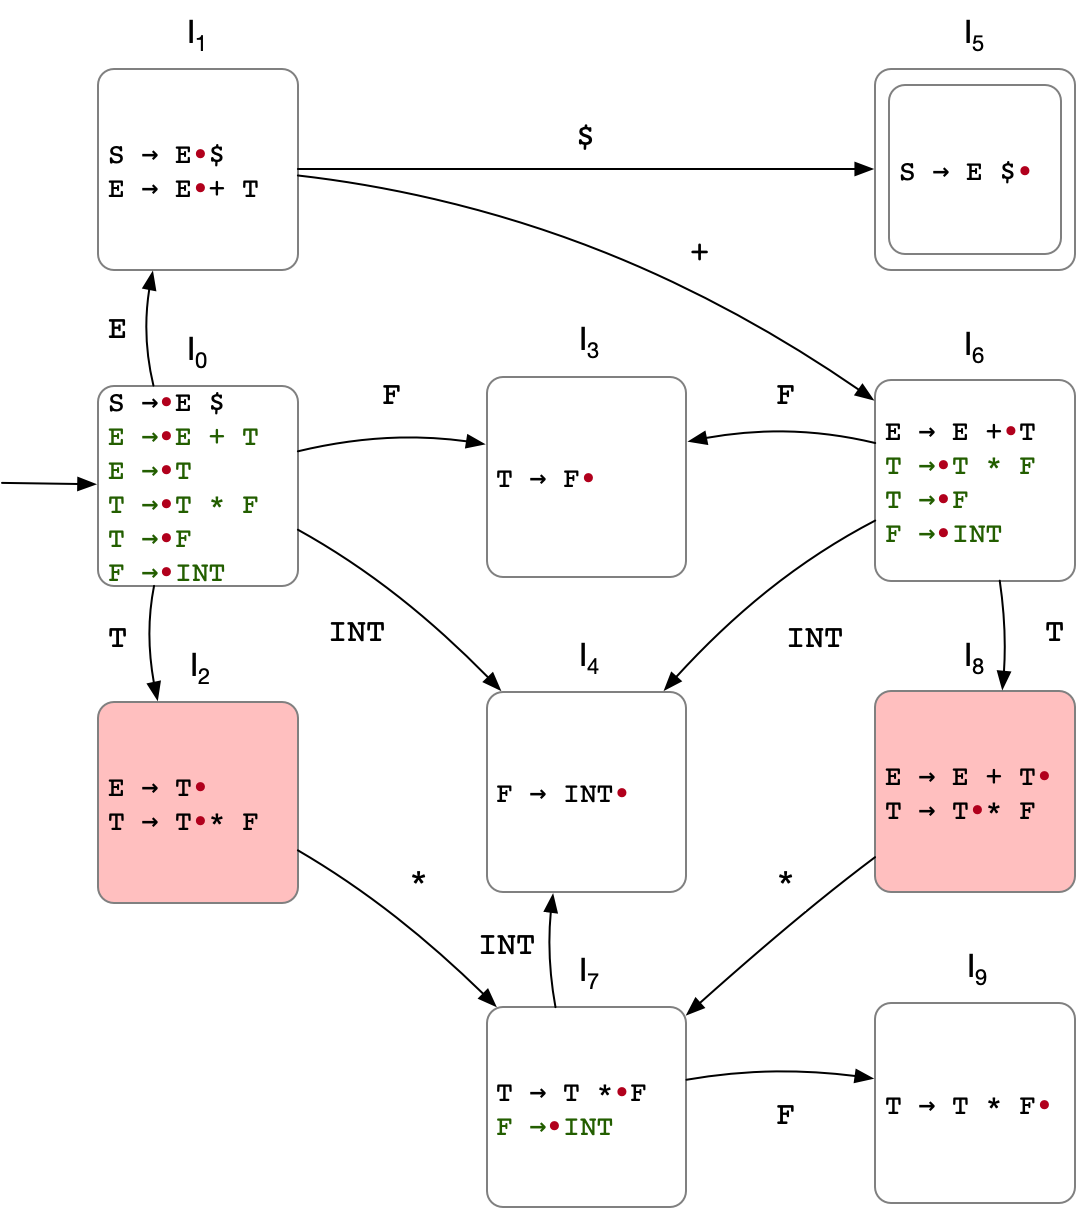

- This has shift/reduce conflicts in states $I_2$ and $I_8$


- To use SLR(1), we should also calculate the $\mathrm{FOLLOW}$ set of the nonterminals being reduced in the conflicting states

- In both, we are trying to reduce `E`:
    - $\mathrm{FOLLOW}(\mathtt{E}) = \{ \mathrm{+}, \mathrm{$} \}$

- If the $\mathrm{FOLLOW}$ set does not conflict with the shifting items of the state, the conflict is resolved
    - In both $I_2$ and $I_8$, we will shift on `*`, which is not in $\mathrm{FOLLOW}(\mathtt{E})$

- We can now construct the parsing tables with these conditional reduces

  | State |`INT`| `+` |`*`  |`$`  |
  | ----- | --- | --- | --- | --- |
  | 0     |`s4` |     |     |     |
  | 1     |     |`s6` |     |`s5` |
  | 2     |     |`r2` |`s7` |`r2` |
  | 3     |     |`r4` |`r4` |`r4` |
  | 4     |     |`r5` |`r5` |`r5` |
  | 5     |`acc`|`acc`|`acc`|`acc`|
  | 6     |`s4` |     |     |     |
  | 7     |`s4` |     |     |     |
  | 8     |     |`r1` |`s7` |`r1` |
  | 9     |     |`r3` |`r3` |`r3` |


  | State |`E`  |`T` |`F` |
  | ----- | --- | -- | -- |
  | 0     | 1   | 2  | 3  |
  | 1     |     |    |    |
  | 2     |     |    |    |
  | 3     |     |    |    |
  | 4     |     |    |    |
  | 5     |     |    |    |
  | 6     |     | 3  | 8  |
  | 7     |     |    | 9  |
  | 8     |     |    |    |
  | 9     |     |    |    |


## Resolving shift/reduce conflicts

There are two main ways to resolve LR conflicts

#### Modify the language
  - In some cases, the conflict reflects a genuine ambiguity in the language
  - Then we may choose to:
    - restrict the language
    - or introduce additional syntax (e.g. delimiters)
  - This is a language design decision, not just a parsing issue

#### Rewrite the grammar
  - A grammar may not be LR(1), even though the language it generates **is** LR(1)
  - Then, the grammar can be **rewritten** into an equivalent grammar that is LR(1)
  - We refine the grammar so that it makes the intended structure explicit
    - introducing new nonterminals
    - separating different structural roles
  - However, understanding and solving LR conflicts is generally less intuitive than in LL parsing
    - Conflicts arise from global parsing context, not just local choices
  - The intuition is that shift/reduce conflicts arise when a string can be both:
    - a complete structure, and
    - a prefix of a larger structure

### ✏️ Resolving LR conflicts example: Dangling else

- Consider a language that allows conditional expressions with:
  - optional else statements
  - no mandatory block delimiters

- Let Σ = { `if`, `then`, `else`, `STMT`, `EXPR` }

  ```
  p1: Conditional → if EXPR then Conditional
  p2:             | if EXPR then Conditional else Conditional
  p3:             | STMT
  ```

- This has a shift/reduce conflict: after `if EXPR then S`, should we reduce with `p1` or shift towards `p2`?

- In fact, this grammar is ambiguous in general:
  - In an expression like `if ... then if ... then ... else ...`, the else can be paired with either `if`

- Resolving this requires choosing a consistent interpretation, and rewrite the grammar

- The convention is to couple the `else` with the closest `if`

- This means that the outer `if` can only have a matching `else` if the inner `if` has its own match:
  - Otherwise, the `else` would belong to the inner `if`

- Let still Σ = { `if`, `then`, `else`, `STMT`, `EXPR` }

  ```
  p1: Conditional → Matched | Unmatched
  p2: Matched     → if EXPR then Matched else Matched
  p3:             | STMT
  p4: Unmatched   → if EXPR then Conditional
  p5:             | if EXPR then Matched else Unmatched
  ```

- This grammar generates the same languages as the previous one, but is now unambiguous and can be parsed deterministically by an LR(1) parser

## Advantages and limitations

- LR parsing are important because it:
  - handles a large class of grammars (more powerful than LL)
  - naturally supports left recursion
  - still efficient, linear-time parsing

- However, there are tradeoffs:
  - more complex to construct and understand
  - parsing tables can be large
  - conflicts can be hard to diagnose
  - less intuitive than top-down parsing

## Bottom-up parsing in practice

- The classic parsing pipeline `lex` / `yacc` implements LALR(1) parsing

- The `Ply` parsing library belongs to this family and also implements LALR(1)

- In practice:
  - grammars are written in a declarative form (productions + actions)
  - parser generators automatically build parsing tables
  - the resulting parser is a table-driven shift-reduce parser

- Real-world grammars are often not conflict-free
  - shift/reduce and reduce/reduce conflicts may arise

- Parser generators typically:
  - report conflicts
  - apply default resolutions (e.g. prefer shift)

- Conflicts can be resolved by:
  - rewriting the grammar
  - providing parser-specific disambiguation instructions
    - for example, specifying operator precedence or associativity (left/right)

### [`Ply.yacc`](https://ply.readthedocs.io/en/latest/ply.html#yacc) basics

- Productions are given by special functions starting with `p_`
  - You can write a different function for each production, or merge them into a single function

- The grammar productions are given in the docstring in Backus–Naur form (BNF)

- The grammar's start symbol is the one defined first

- The terminals of the grammar are the token types of the lexer
  - Usually, a `Ply.lex` lexer, but could be any other implementation

- The semantic actions are executed in *reduce* steps
  - Production functions process the return values of their children and return values up

- Each `p_` function receives as argument a sequence of values:
  - position 0 is reserved for its return value
  - positions from 1 onwards are the values returned by the children nodes

- The value of tokens (terminals) is the one assigned by the lexer

- Example:
  ```python
  def p_expr(p):
      """
      E   :   E   '+'   T
      """
  #   ^       ^    ^    ^
  #  p[0]    p[1] p[2] p[3]
      p[0] = p[1] + p[3]
  ```  


📌 You can actually check the construction of the DFA and the parsing tables by inspecting `Ply.yacc` auxiliary files `parser.out` and `parsetab.py`.

⚠️ *Note:* since `Ply` relies on reflection, it is not prone to having multiple specifications in the same module
  - This leads to some conflicts when writing specifications in notebooks, which is not recommended
  - Either run the code outside the notebook, or restart the notebook session if it becomes corrupted


### ✏️ `Ply.yacc` example: A language for lists

- Let's again recall our grammar for lists, with Σ = { `INT`, `[`, `]`, `,` } and $S_0$ = `E`
    - This grammar was not LL(1) and is also not LR(0), but it is LALR(1)

  ```
  p1: List → [ Elements ]
  p2:      | [ ]
  p3: Elements → INT
  p4:          | INT , Elements
  ```

- We can define the lexer using any mechanism, but we will stick with `Ply.lex`

In [ ]:
import ply.lex as lex

class LexError(Exception):
    pass

tokens = ("INT",)
literals = "[],"

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t\n"

def t_error(t):
  raise LexError(f"Invalid symbol: {t.value[0]}")

lexer = lex.lex()

- If we just want to recognize inputs, we can just write a single `p_` function and document it with the grammar

In [ ]:
import ply.yacc as yacc

def p_parser(p):
    # notice that Ply.lex literal tokens need quotes
    r"""
    List : '[' Elements ']'
         | '[' ']'
    Elements : INT
             | INT ',' Elements
    """

class ParseError(Exception):
    pass

def p_error(t):
    raise ParseError(f"Unexpected token: {t.type if t else '$'}") # ply assumes None at end of input

parser = yacc.yacc(write_tables=False) # arguments to avoid conflicts in notebook

def parse(text):
  try:
    parser.parse(text)
    print("Parsed successfully")
  except ParseError as e:
    print("Parsed failed:", e)

Generating LALR tables


In [ ]:
parse("[1, 2, 4]")

In [ ]:
parse("[]")

In [ ]:
parse("[1, 4, ]")

### ✏️ `Ply.yacc` example: Simple arithmetic expressions

- Let us again consider the following grammar for arithmetic expressions, with Σ = { `INT`, `+`, `-`, `*`, `/` } and $S_0$ = `E`

  ```
  p1: E → E + T
  p2:   | E - T
  p3:   | T
  p4: T → T * F
  p5:   | T / F
  p6:   | F
  p7: F → INT
  ```

- First, the lexer

In [ ]:
import ply.lex as lex

tokens = ("INT",)
literals = "+*/-"

def t_INT(t):
  r"\d+"
  t.value = int(t.value)
  return t

t_ignore = " \t\n"

def t_error(t):
    raise LexError(f"Invalid symbol: {t.value[0]}")

lexer = lex.lex()

- If we just want to recognize inputs, we can just write a single `p_` function and document it with the grammar

In [ ]:
import ply.yacc as yacc

def p_parser(p):
    # notice that Ply.lex literal tokens need quotes
    r"""
    E  : E "+" T
       | E "-" T
       | T
    T  : T "*" F
       | T "/" F
       | F
    F  : INT
    """

class ParseError(Exception):
    pass

def p_error(t):
    raise ParseError(f"Unexpected token: {t.type if t else '$'}") # ply assumes None at end of input

parser = yacc.yacc(write_tables=False) # arguments to avoid conflicts in notebook

def parse(text):
  try:
    parser.parse(text)
    print("Parsed successfully")
  except ParseError as e:
    print("Parsed failed:", e)

Generating LALR tables


In [ ]:
parse("1 + 2 * 3")

Parsed successfully


In [ ]:
parse("12")

Parsed successfully


In [ ]:
parse("1 - 2 *")

Parsed failed: Unexpected token: $


In [ ]:
parse("1 + 2 + * 3")

Parsed failed: Unexpected token: *


### Resolving conflicts in `Ply.yacc`

- When conflicts are found by `Ply.yacc`, the parser generator makes implicits decisions:
  - in shift/reduce conflicts, always choose shift
  - in reduce/reduce conflicts, always choose the production defined first
  
- Relying on this is bad practice: it often means that the grammar is ambiguous, allowing multiple interpretations
  - You should revisit the grammar and remove ambiguities

- Often, ambiguity is caused by a lack of operator precedence or associativity policy

- Parser generators have specific support for solving such conflicts
  - In `Ply.yacc` this is done by defining a special variable `precedences`

- This is still not a good practice, since the grammar alone does not reflect the syntactic structure of the language

### ✏️ `Ply.yacc` precedences example: Simple arithmetic expressions

- Let us again consider the following grammar for arithmetic expressions, with Σ = { `INT`, `+`, `-`, `*`, `/` } and $S_0$ = `E`

  ```
  p1: E → E + E
  p2:   | E - E
  p3:   | E * E
  p5:   | E / E
  p6:   | F
  p7: F → INT
  ```

- As we've already seen this grammar is ambiguous (and thus, not LR(1)), since it allows different interpretations regarding precedences and associativity

In [ ]:
import ply.yacc as yacc

def p_parser(p):
    # notice that Ply.lex literal tokens need quotes
    r"""
    E  : E "+" E
       | E "-" E
       | E "*" E
       | E "/" E
       | F
    F  : INT
    """

class ParseError(Exception):
    pass

def p_error(t):
    raise ParseError(f"Unexpected token: {t.type if t else '$'}") # ply assumes None at end of input

parser = yacc.yacc(write_tables=False) # arguments to avoid conflicts in notebook

def parse(text):
  try:
    parser.parse(text)
    print("Parsed successfully")
  except ParseError as e:
    print("Parsed failed:", e)

Generating LALR tables


- However, this ambiguity can be resolved by imposing precedence and associativity rules

In [ ]:
import ply.yacc as yacc

def p_parser(p):
    # notice that Ply.lex literal tokens need quotes
    r"""
    E  : E "+" E
       | E "-" E
       | E "*" E
       | E "/" E
       | F
    F  : INT
    """

precedence = (
    ('left', '+', '-'),
    ('left', '*', '/'),
)

class ParseError(Exception):
    pass

def p_error(t):
    raise ParseError(f"Unexpected token: {t.type if t else '$'}") # ply assumes None at end of input

parser = yacc.yacc(write_tables=False) # arguments to avoid conflicts in notebook

def parse(text):
  try:
    parser.parse(text)
    print("Parsed successfully")
  except ParseError as e:
    print("Parsed failed:", e)

Generating LALR tables


### Semantic actions in bottom-up parsing

- When implementing a recursive descendent parser, we were able to both
  - pass information down in the recursive calls
  - process information upwards after those calls returned

- In shift-reduce parsers we are more limited:
  - semantic actions can only be assigned to reduce steps
  - since the parser acts bottom-up it is not as easy to pass information downward

### ✏️ `Ply.yacc` evaluation example: Simple arithmetic expressions

- Let us again consider the following grammar for arithmetic expressions, with Σ = { `INT`, `+`, `-`, `*`, `/` } and $S_0$ = `E`

  ```
  p1: E → E + T
  p2:   | E - T
  p3:   | T
  p4: T → T * F
  p5:   | T / F
  p6:   | F
  p7: F → INT
  ```

- `Ply.yacc` will collect all productions prefixed with `p_`, so the easiest way to add semantic actions is to split the grammar into multiple functions

In [ ]:
import ply.yacc as yacc

def p_expr_add(p):
    r"""
    E  : E "+" T
    """
    # p[0] is the value of the new E being created
    # p[1] is the value of the E already created,  p[2] of the "+" and p[3] of the T
    p[0] = p[1] + p[3]
    # no return values

def p_expr_sub(p):
    r"""
    E  : E "-" T
    """
    p[0] = p[1] - p[3]

def p_expr_term(p):
    r"""
    E  : T
    """
    p[0] = p[1]

def p_term_mul(p):
    r"""
    T  : T "*" F
    """
    p[0] = p[1] * p[3]

def p_term_div(p):
    r"""
    T  : T "/" F
    """
    p[0] = p[1] / p[3]

def p_term_factor(p):
    r"""
    T  : F
    """
    p[0] = p[1]

def p_factor(p):
    r"""
    F  : INT
    """
    # terminals get the values provided by the lexer
    p[0] = p[1]

class ParseError(Exception):
    pass

def p_error(t):
    raise ParseError(f"Unexpected token: {t.type if t else '$'}") # ply assumes None at end of input

parser = yacc.yacc(write_tables=False) # arguments to avoid conflicts in notebook

def parse(text):
  try:
    return parser.parse(text)
  except ParseError as e:
    print("Parsed failed:", e)

Generating LALR tables


In [ ]:
parse("1 + 2 * 3")

7

In [ ]:
parse("12")

12

## 🛠 `Ply.yacc` exercise: Shopping list

- We want to design a language to allow writing shopping lists

- It should have the following features:
  - Each list is a list of categories with a description
  - Each category is a list of items with a quantity and an optional textual note

- Design such a language for this purpose and:
  - Specify a CFG to recognize it
  - Implement a lexer and a parser using `Ply`
  - Convert the list into Markdown
  - Extract the list as a Python dictionary

-- Nuno Macedo, 2026-04-14